# ЛР №5. Запуск открытой модели text-to-image

**Выполнил:** Яковенко Максим Михайлович, группа МИК11 (Т26ИИКТ-МИК11)

**Вариант 2.** По формуле раздела 7 методических указаний
N = (номер брифа − 1) · 6 + номер условия = (1 − 1) · 6 + 2 = 2:

| | |
| --- | --- |
| Бриф | 1 — афиша фестиваля робототехники (силуэт механической руки, синий и янтарный) |
| Условие сравнения | 2 — seed и seed + 1 (`seed_plus_1`) |
| seed варианта | 1000 + N = **1002**; сравниваемый запуск B — seed 1003 |
| Модель | `stabilityai/sd-turbo`, ревизия `b261bac6fd2cf515557d5d0707481eafa0485ec2` |
| Фиксировано | 512 × 512, 1 шаг, `guidance_scale = 0,0`, генератор на CPU, метрики и допуск 40 дБ |
| Устройство и точность | GPU (`cuda`), float16 — как в указаниях; библиотека без изменений |

**Репозиторий работы:** https://github.com/ykvnkm/ai-in-creative-industries/tree/main/LR05

Ноутбук построен по плану раздела 5 (шаги 1–8). Перед каждой ячейкой кода — пояснение:
что она делает и зачем. Все функции модели и сравнения берутся из выданной библиотеки
`lab05_lib.py` без изменений: код преподавателя (`"cuda"`,
float16) исполняется как есть. На случай, если CUDA в сеансе окажется недоступна,
предусмотрен запасной путь на CPU (раздел «Запасной путь без GPU»); если он сработает,
это записывается в манифест и паспорт как изменение условий.

## Данные и лицензия

Входные данные — только текст запроса: бриф 1 из списка `BRIEFS` библиотеки
(«editorial poster concept for a robotics festival, glowing mechanical arm silhouette,
deep blue and amber palette, clean composition, no text, no logo, no people»).
В запросе нет реальных людей, логотипов, названий производителей и закрытых материалов;
изображение — концепт, а не иллюстрация реального устройства.

Модель распространяется по **Stability AI Community License Agreement** (файл `LICENSE.md`
в репозитории модели на закреплённой ревизии): некоммерческое и учебное использование
допускается, при распространении сохраняется уведомление о лицензии и указание
«Powered by Stability AI»; действует политика допустимого использования (Acceptable Use Policy).
Работа выполняется в учебных, некоммерческих целях. Ссылка:
https://huggingface.co/stabilityai/sd-turbo/blob/b261bac6fd2cf515557d5d0707481eafa0485ec2/LICENSE.md

**Оценка времени выполнения.** Весь ноутбук делает 10 генераций 512 × 512 по одному шагу
(прогрев, базовый запуск, повтор, пара A/B в `variant_summary`, B для сохранения, две генерации
эксперимента о причине различия, два запуска с общим генератором) и ещё 5 в демонстрационном
скрипте преподавателя. На GPU в float16 одна генерация занимает доли секунды (в демо на T4 —
0,3 с), загрузка модели — десятки секунд, поэтому основное время уходит на однократное
скачивание весов (≈ 2,6 ГБ, файлы fp16). Ожидаемое общее время — **несколько минут плюс
загрузка весов**; повторный прогон с уже скачанными весами — 1–2 мин. На запасном пути без
GPU (CPU, float32) генерация занимает 10–40 с, общее время — 5–20 мин.
Фактически в Colab на T4: загрузка модели со скачиванием весов 65,8 с, одна генерация 0,33 с,
весь ноутбук без демонстрационного скрипта — 4,2 мин.

## Шаг 1. Подготовка среды

Ячейка создаёт рабочую папку `LR05` в текущем каталоге и переходит в неё: все файлы
(библиотека, артефакты) записываются по абсолютному пути внутри `WORK`.

Затем проверяется наличие пакетов. Отсутствующие ставятся через `pip` того же
интерпретатора, что исполняет ноутбук: `torch` — стандартная сборка из PyPI (для Linux
она идёт с поддержкой CUDA), `diffusers` — версии 0.40.0, на которой
преподаватель проверял библиотеку. Уже установленные пакеты не трогаются.

**Версии пакетов.** Методические указания проверены на diffusers 0.40.0 и transformers 5.16.1; эти версии ставятся, если в окружении другие. Им нужен `torch` ≥ 2.6; при более старом `torch` ставятся последние совместимые с ним версии (diffusers 0.32.2, transformers 4.48.3), а сам `torch` не меняется. Версия `torch` проверяется по метаданным пакета, без импорта. Фактические версии печатаются ниже и попадают в паспорт эксперимента.


In [1]:
import os, sys, time, shutil, pathlib, platform, importlib, subprocess

T_START = time.perf_counter()
WORK = pathlib.Path.cwd() / "LR05"
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
if str(WORK) not in sys.path:
    sys.path.insert(0, str(WORK))
print("Рабочая папка:", WORK)


def missing(module):
    try:
        importlib.import_module(module)
        return False
    except ImportError:
        return True


def pip_install(*args):
    print("pip install", " ".join(args))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)


# torch проверяется по метаданным пакета, без импорта: старый torch, загруженный в ядро, нельзя заменить на лету.
import re, shutil
from importlib.metadata import version as pkg_version, PackageNotFoundError


def installed_version(pkg):
    try:
        return pkg_version(pkg)
    except PackageNotFoundError:
        return None


def at_least(v, need):
    return v is not None and tuple(int(x) for x in re.findall(r"\d+", v.split("+")[0])[:2]) >= need


TORCH_V = installed_version("torch")
HAS_GPU = shutil.which("nvidia-smi") is not None or os.path.exists("/dev/nvidia0")
print("torch в окружении:", TORCH_V, "| GPU в сеансе:", HAS_GPU)
if TORCH_V is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"], check=True)
    raise SystemExit("torch установлен. Перезапустите ядро (Restart) и выполните ноутбук с первой ячейки.")
# Версии указаний (diffusers 0.40, transformers 5) требуют torch >= 2.6; при старом torch — совместимые с ним.
PINS = ({"diffusers": "0.40.0", "transformers": "5.16.1"} if at_least(TORCH_V, (2, 6))
        else {"diffusers": "0.32.2", "transformers": "4.48.3"})
todo = [f"{k}=={v}" for k, v in PINS.items() if installed_version(k) != v]
if todo:
    print("устанавливаю:", " ".join(todo))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *todo], check=True)
    importlib.invalidate_caches()
    if any(m in sys.modules for m in PINS):   # пакет уже был загружен в это ядро — нужна перезагрузка
        raise SystemExit("Пакеты обновлены. Перезапустите ядро (Restart) и выполните ноутбук с первой ячейки.")
print("версии diffusers/transformers:", PINS)
need = [pkg for pkg, mod in [("diffusers==0.40.0", "diffusers"), ("transformers", "transformers"),
                             ("accelerate", "accelerate"), ("safetensors", "safetensors"),
                             ("Pillow", "PIL")] if missing(mod)]
if need:
    pip_install(*need)
importlib.invalidate_caches()
print("Недостающие пакеты:", need or "нет")

Рабочая папка: /content/LR05
torch в окружении: 2.11.0+cu130 | GPU в сеансе: True
устанавливаю: transformers==5.16.1
версии diffusers/transformers: {'diffusers': '0.40.0', 'transformers': '5.16.1'}
Недостающие пакеты: нет


Следующая ячейка фиксирует среду для манифеста и паспорта: версии Python и библиотек,
платформу, устройство вычислений: имя видеокарты и её память (аналог `nvidia-smi`), а при
отсутствии CUDA — модель процессора из `/proc/cpuinfo`. Объём ОЗУ берётся из `/proc/meminfo`. Также выводится
свободное место на диске: веса модели в кэше Hugging Face занимают около 2,6 ГБ.
Это аналог команд `nvidia-smi` и `pip list` из раздела 4 указаний.

In [2]:
import numpy as np
import torch, diffusers, transformers, PIL


def cpu_name():
    try:
        with open("/proc/cpuinfo", encoding="utf-8") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except OSError:
        pass
    return platform.processor() or platform.machine()


def ram_gib():
    try:
        with open("/proc/meminfo", encoding="utf-8") as f:
            for line in f:
                if line.startswith("MemTotal"):
                    return round(int(line.split()[1]) / 1024 ** 2, 1)
    except OSError:
        pass
    return None


CUDA = torch.cuda.is_available()
DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA else cpu_name()
HF_CACHE = pathlib.Path(os.environ.get("HF_HOME", pathlib.Path.home() / ".cache" / "huggingface"))
HF_CACHE.mkdir(parents=True, exist_ok=True)

print("Python      ", sys.version.split()[0])
print("Платформа   ", platform.platform())
print("torch       ", torch.__version__)
print("diffusers   ", diffusers.__version__)
print("transformers", transformers.__version__)
print("Pillow      ", PIL.__version__)
print("numpy       ", np.__version__)
print("CUDA        ", CUDA)
print("Устройство  ", DEVICE_NAME)
if CUDA:
    print("Память GPU, ГиБ:", round(torch.cuda.get_device_properties(0).total_memory / 1024 ** 3, 1),
          "| CUDA в torch:", torch.version.cuda)
print("Ядер CPU    ", os.cpu_count(), "| потоков torch:", torch.get_num_threads())
print("ОЗУ, ГиБ    ", ram_gib())
print("Свободно на диске (кэш HF), ГиБ:", round(shutil.disk_usage(HF_CACHE).free / 1024 ** 3, 1), "|", HF_CACHE)

Python       3.13.15
Платформа    Linux-6.6.122+-x86_64-with-glibc2.39
torch        2.11.0+cu130
diffusers    0.40.0
transformers 5.16.1
Pillow       11.3.0
numpy        2.1.3
CUDA         True
Устройство   Tesla T4
Память GPU, ГиБ: 14.6 | CUDA в torch: 13.0
Ядер CPU     2 | потоков torch: 1
ОЗУ, ГиБ     12.7
Свободно на диске (кэш HF), ГиБ: 70.1 | /root/.cache/huggingface


## Шаг 1 (продолжение). Библиотека преподавателя

По разделу 4 указаний библиотека вводится в ноутбук ячейкой `%%writefile`. Текст ниже
скопирован из приложения А без единой правки: магическая команда записывает его в файл
`lab05_lib.py` в рабочей папке.

In [3]:
%%writefile lab05_lib.py
# ЛР 5. Запуск открытой модели text-to-image. Библиотека учебных функций.
# Проверено 19.09.2026: Google Colab, GPU T4, Python 3.13, torch 2.11.0+cu128, diffusers 0.40.0, transformers 5.16.1.
# Модель: stabilityai/sd-turbo, ревизия закреплена (см. REVISION). Веса загружаются с Hugging Face без авторизации.
import hashlib, io, time
import numpy as np
import torch
from PIL import Image
from diffusers import AutoPipelineForText2Image
from diffusers.utils import logging as dlog

dlog.set_verbosity_error()  # убирает предупреждения о приведении типов при pipe.to(dtype)

MODEL_ID = "stabilityai/sd-turbo"
REVISION = "b261bac6fd2cf515557d5d0707481eafa0485ec2"

# Пять контекстов (брифов). Во всех запретены текст, логотипы и люди.
BRIEFS = [
    "editorial poster concept for a robotics festival, glowing mechanical arm silhouette, deep blue and amber palette, clean composition, no text, no logo, no people",
    "square podcast cover about the city environment, abstract layered skyline of geometric shapes, teal and orange palette, minimal flat style, no text, no people",
    "poster concept for a science exhibition, abstract constellation of connected nodes, dark background with white and cyan lines, balanced composition, no text, no logo",
    "visual for an ecology lecture series, stylized forest canopy seen from above, layered green shapes, soft morning light, no text, no people",
    "cover art for an electronic music release, brushed metal surface with iridescent reflections, macro photography style, strong contrast, no text, no logo, no people",
]


def load_pipe(dtype=torch.float16):
    """Загружает закреплённую ревизию (файлы fp16) на GPU; dtype задаёт тип вычислений."""
    pipe = AutoPipelineForText2Image.from_pretrained(
        MODEL_ID, revision=REVISION, torch_dtype=torch.float16, variant="fp16", use_safetensors=True)
    pipe.set_progress_bar_config(disable=True)
    return pipe.to("cuda", dtype)


def generate(pipe, prompt, seed, steps=1, guidance=0.0, size=512, batch=1, gen_device="cpu"):
    """Возвращает список PIL-изображений. Для каждого элемента пакета свой генератор: seed, seed+1, ..."""
    gens = [torch.Generator(device=gen_device).manual_seed(seed + i) for i in range(batch)]
    return pipe(prompt=[prompt] * batch, num_inference_steps=steps, guidance_scale=guidance,
                height=size, width=size, generator=gens).images


def generate_fixed_noise(pipe, prompt, seed, steps=1, guidance=0.0, size=512):
    """Начальный шум всегда строится в float32 и приводится к типу вычислений: так меняется только точность."""
    g = torch.Generator(device="cpu").manual_seed(seed)
    lat = torch.randn((1, 4, size // 8, size // 8), generator=g, dtype=torch.float32).to("cuda", pipe.unet.dtype)
    return pipe(prompt=[prompt], num_inference_steps=steps, guidance_scale=guidance, height=size, width=size, latents=lat).images[0]


def png_bytes(img):
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return buf.getvalue()


def sha(data):
    return hashlib.sha256(data).hexdigest()


def to_arr(img):
    return np.asarray(img.convert("RGB"), dtype=np.float64)


def psnr_db(a, b):
    """PSNR для значений 0..255; inf, если изображения совпадают."""
    mse = np.mean((to_arr(a) - to_arr(b)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)


def max_abs_diff(a, b):
    return int(np.max(np.abs(to_arr(a) - to_arr(b))))


def jpeg_roundtrip(img, quality=90):
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB"), buf.getvalue()


def classify(psnr, tol_db=40.0):
    """Классификация пары по допуску, заданному до эксперимента."""
    return "identical" if psnr == float("inf") else ("close" if psnr >= tol_db else "different")


# Шесть условий сравнения (фактор варианта). Каждое условие даёт пару изображений A и B.
CONDITIONS = ["repeat", "seed_plus_1", "generator_device", "dtype", "file_format", "batch"]


def make_pair(pipe, prompt, seed, cond):
    if cond == "repeat":
        a = generate(pipe, prompt, seed)[0]; b = generate(pipe, prompt, seed)[0]
    elif cond == "seed_plus_1":
        a = generate(pipe, prompt, seed)[0]; b = generate(pipe, prompt, seed + 1)[0]
    elif cond == "generator_device":
        a = generate(pipe, prompt, seed, gen_device="cpu")[0]; b = generate(pipe, prompt, seed, gen_device="cuda")[0]
    elif cond == "dtype":
        pipe.to(torch.float16); a = generate(pipe, prompt, seed)[0]
        pipe.to(torch.float32); b = generate(pipe, prompt, seed)[0]
        pipe.to(torch.float16)
    elif cond == "file_format":
        a = generate(pipe, prompt, seed)[0]; b, _ = jpeg_roundtrip(a, 90)
    elif cond == "batch":
        a = generate(pipe, prompt, seed)[0]; b = generate(pipe, prompt, seed, batch=4)[0]
    else:
        raise ValueError(cond)
    return a, b


def variant_summary(pipe, n):
    """Вариант n = 1..30: контекст c = (n-1)//6 + 1, условие k = (n-1)%6 + 1."""
    c, k = (n - 1) // 6, (n - 1) % 6
    seed = 1000 + n
    t0 = time.perf_counter()
    a, b = make_pair(pipe, BRIEFS[c], seed, CONDITIONS[k])
    dt = time.perf_counter() - t0
    p = psnr_db(a, b)
    pf = None
    if CONDITIONS[k] == "dtype":  # проверка причины: одинаковый начальный шум в обоих режимах
        pipe.to(torch.float16); fa = generate_fixed_noise(pipe, BRIEFS[c], seed)
        pipe.to(torch.float32); fb = generate_fixed_noise(pipe, BRIEFS[c], seed)
        pipe.to(torch.float16); pf = psnr_db(fa, fb)
    return dict(variant=n, ctx=c + 1, cond=CONDITIONS[k], seed=seed, sha_a=sha(png_bytes(a)), sha_b=sha(png_bytes(b)),
                pixel_equal=bool(np.array_equal(to_arr(a), to_arr(b))), max_diff=max_abs_diff(a, b), psnr=p,
                verdict=classify(p), seconds=round(dt, 2), psnr_fixed_noise=pf)


Writing lab05_lib.py


Проверка целостности: размер и SHA-256 записанного файла сравниваются со значениями
из указаний (6447 байт, SHA-256 начинается с `4eb17650`). Совпадение доказывает, что
библиотека введена побитово так же, как у преподавателя. Если редактор ячеек
отбросил завершающий перевод строки (в оригинале файл им заканчивается), ячейка
восстанавливает его и сообщает об этом — других изменений не делается.

In [4]:
import hashlib

LIB_PATH = WORK / "lab05_lib.py"
lib_bytes = LIB_PATH.read_bytes()
if not lib_bytes.endswith(b"\n") and hashlib.sha256(lib_bytes + b"\n").hexdigest().startswith("4eb17650"):
    lib_bytes += b"\n"
    LIB_PATH.write_bytes(lib_bytes)
    print("Восстановлен завершающий перевод строки, отброшенный редактором ячейки")
LIB_SHA = hashlib.sha256(lib_bytes).hexdigest()
print("Размер, байт:", len(lib_bytes))
print("SHA-256     :", LIB_SHA)
LIB_OK = len(lib_bytes) == 6447 and LIB_SHA.startswith("4eb17650")
print("Совпадает с указаниями (6447 байт, 4eb17650…):", LIB_OK)
assert LIB_OK, "библиотека введена с ошибкой — сверить текст ячейки с приложением А"

Размер, байт: 6447
SHA-256     : 4eb176506585ffcda1702605a767309fb451808229c3622f80ce882b7fa2ce1a
Совпадает с указаниями (6447 байт, 4eb17650…): True


## Запасной путь без GPU

Основной путь: GPU доступен, `torch.cuda.is_available()` возвращает `True`, и
библиотека импортируется как есть — с устройством `"cuda"` и float16, как в указаниях
и в демо преподавателя. Ячейка тогда только сообщает, что адаптация не применялась.

Запасной путь нужен, если в сеансе CUDA окажется недоступна (например, ноутбук запущен
на машине без видеокарты). Библиотека жёстко задаёт `"cuda"` и float16, а float16 на CPU
частью операций не поддерживается или работает в разы медленнее float32. Тогда файл
`lab05_lib.py` **не меняется** (его SHA-256 уже сверен), а в памяти из его текста
собирается модуль с двумя заменами: `"cuda"` → `"cpu"` (во всех вхождениях) и тип
вычислений по умолчанию float16 → float32; веса загружаются из тех же файлов fp16 и
приводятся к float32. Остальные функции остаются функциями преподавателя, а ячейка
выводит, что заменено и сколько раз. Это было бы **записанным изменением условий**:
оно попадает в манифест (`lib_adaptation`) и паспорт; при float32 начальный шум при том же
seed другой (раздел 6.5 указаний), так что SHA-256 не сопоставимы с запуском на GPU.
На условие варианта (seed и seed + 1 в одной среде) это не влияет.

In [5]:
import types, difflib

LIB_TEXT = lib_bytes.decode("utf-8")
if CUDA:
    import lab05_lib as L
    ADAPTATION = "нет: CUDA доступна, библиотека используется без изменений"
    ADAPTED_TEXT = LIB_TEXT
else:
    REPLACEMENTS = [('"cuda"', '"cpu"'),
                    ("def load_pipe(dtype=torch.float16):", "def load_pipe(dtype=torch.float32):")]
    ADAPTED_TEXT, ADAPTATION = LIB_TEXT, []
    for old, new in REPLACEMENTS:
        n = ADAPTED_TEXT.count(old)
        ADAPTED_TEXT = ADAPTED_TEXT.replace(old, new)
        ADAPTATION.append(f"{old} -> {new}: замен {n}")
    L = types.ModuleType("lab05_lib")
    L.__file__ = str(LIB_PATH)
    exec(compile(ADAPTED_TEXT, "lab05_lib.py (CPU-адаптация в памяти)", "exec"), L.__dict__)
    sys.modules["lab05_lib"] = L
    print("Замены:")
    for a in ADAPTATION:
        print("  ", a)
    print("\nИзменённые строки:")
    for line in difflib.unified_diff(LIB_TEXT.splitlines(), ADAPTED_TEXT.splitlines(),
                                     "lab05_lib.py", "адаптация", n=0, lineterm=""):
        print(line)
ADAPTED_SHA = hashlib.sha256(ADAPTED_TEXT.encode("utf-8")).hexdigest()
print("\nSHA-256 исполняемого текста библиотеки:", ADAPTED_SHA)
print("Модель:", L.MODEL_ID, "| ревизия:", L.REVISION)

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.



SHA-256 исполняемого текста библиотеки: 4eb176506585ffcda1702605a767309fb451808229c3622f80ce882b7fa2ce1a
Модель: stabilityai/sd-turbo | ревизия: b261bac6fd2cf515557d5d0707481eafa0485ec2


## Шаг 2. Гипотеза и допуск (записаны до запуска)

Гипотеза и допуск зафиксированы в репозитории в `reports/journal.md` **до первого
запуска** этого ноутбука; здесь они повторены без изменений.

**Допуск** (раздел 2.3 указаний, 40 дБ): пара A/B — «идентичная» (identical) при
побитовом совпадении пикселей, «практически совпадающая» (close) при PSNR ≥ 40 дБ,
«различная» (different) при PSNR < 40 дБ.

**Гипотеза для условия 2 (seed 1002 против seed 1003).** Ожидаю вердикт **different**:
SHA-256 A и B различны, пиксели не совпадают, максимум различия близок к 255,
PSNR **порядка 8–15 дБ**, то есть намного ниже 40 дБ. Обоснование: seed задаёт только
начальный шум латентного пространства; соседний seed даёт статистически независимый шум,
а при одном шаге sd-turbo изображение почти целиком определяется этим шумом. Различие —
не нестабильность модели, а смена входа. Ориентир — намеренная ошибка в демо указаний,
где второй запуск тоже получает другой шум: PSNR 11,14 дБ.
При этом запрос один и тот же, поэтому ожидаю, что на **обоих** изображениях силуэт
механической руки узнаётся и остаётся главным объектом кадра, а палитра синий/янтарный
сохраняется; меняются поза, композиция и детали.

**Сопутствующие ожидания.** Повтор с тем же seed и свежим генератором в одном сеансе —
побитовое совпадение SHA-256. Общий генератор на два вызова — первое изображение совпадает
с эталоном, второе нет (PSNR < 40 дБ). Запуск идёт на GPU во float16, как в указаниях;
побитового совпадения с изображениями указаний для своего seed не проверяю: другая модель видеокарты и
другие версии torch/CUDA допускают различия «в пределах допуска» (раздел 2.2), а seed
варианта отличается от демо.

## Шаг 3. Загрузка модели и прогрев

`L.load_pipe()` загружает конвейер `AutoPipelineForText2Image` закреплённой ревизии
(при первом запуске веса скачиваются с Hugging Face, затем берутся из кэша) и переносит
его на GPU во float16 (на запасном пути без GPU — на CPU во float32). Время загрузки измеряется для
манифеста. Прогревочный вызов, как в демо указаний, делается с посторонним seed 1: первый
вызов включает однократные накладные расходы, и без прогрева время базового запуска было
бы завышено. Сам прогрев на результаты не влияет — каждый запуск создаёт свой генератор.

In [6]:
t0 = time.perf_counter()
pipe = L.load_pipe()
load_s = time.perf_counter() - t0
DTYPE = str(pipe.unet.dtype).replace("torch.", "")
print(f"Загрузка модели: {load_s:.1f} с | устройство конвейера: {pipe.device} | тип вычислений: {DTYPE}")

t0 = time.perf_counter()
L.generate(pipe, L.BRIEFS[0], 1)
print(f"Прогрев (seed 1): {time.perf_counter() - t0:.1f} с")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Загрузка модели: 65.8 с | устройство конвейера: cuda:0 | тип вычислений: float16
Прогрев (seed 1): 3.8 с


## Шаг 4. Базовый запуск и манифест

Базовый запуск по брифу 1 с seed варианта 1002 и фиксированными параметрами
(1 шаг, guidance 0,0, 512 × 512, генератор на CPU). Код повторяет демонстрационный
пример указаний: PNG сохраняется в `artifacts/run_001/result.png`, рядом —
`manifest.json` с полями демо (модель, ревизия, запрос, seed, шаги, guidance, размер,
устройство генератора, тип вычислений, устройство, платформа, версии, время, размер и
режим изображения, SHA-256). Дополнительно в манифест записаны SHA-256 файла библиотеки, сведения об адаптации
(на GPU — «нет») и SHA-256 исполняемого текста библиотеки.

Затем — повтор со свежим генератором и тем же seed: SHA-256 должен совпасть.

**Проверка в новом сеансе.** Если `run_001` уже существует (ноутбук выполняется второй
раз после перезапуска ядра), результат пишется в следующую папку `run_002`, и его SHA-256
сравнивается с `run_001` предыдущего сеанса. В Colab после удаления среды выполнения
папка `artifacts/` создаётся заново пустой, поэтому результат снова попадает в `run_001`, а сверка
с первым сеансом выполняется следующей ячейкой по записанному SHA-256 первого сеанса.

Папка запуска: /content/LR05/artifacts/run_001
{
  "model_id": "stabilityai/sd-turbo",
  "revision": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
  "prompt": "editorial poster concept for a robotics festival, glowing mechanical arm silhouette, deep blue and amber palette, clean composition, no text, no logo, no people",
  "seed": 1002,
  "steps": 1,
  "guidance_scale": 0.0,
  "size": 512,
  "generator_device": "cpu",
  "dtype": "float16",
  "device": "Tesla T4",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "python": "3.13.15",
  "packages": {
    "torch": "2.11.0+cu130",
    "diffusers": "0.40.0",
    "transformers": "5.16.1",
    "pillow": "11.3.0"
  },
  "load_seconds": 65.8,
  "generation_seconds": 0.33,
  "image_size": [
    512,
    512
  ],
  "image_mode": "RGB",
  "sha256": "403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d",
  "lib_sha256": "4eb176506585ffcda1702605a767309fb451808229c3622f80ce882b7fa2ce1a",
  "lib_adaptation": "нет: CUDA доступна, библи

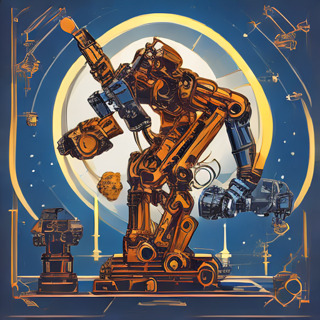

In [7]:
import json
from IPython.display import display

N = 2
PROMPT, SEED, STEPS, GUIDANCE, SIZE = L.BRIEFS[0], 1000 + N, 1, 0.0, 512
ART = WORK / "artifacts"
k = 1
while (ART / f"run_{k:03d}" / "manifest.json").exists():
    k += 1
out = ART / f"run_{k:03d}"
out.mkdir(parents=True, exist_ok=True)

t0 = time.perf_counter()
img = L.generate(pipe, PROMPT, SEED, STEPS, GUIDANCE, SIZE)[0]
gen_s = time.perf_counter() - t0

data = L.png_bytes(img)
(out / "result.png").write_bytes(data)
manifest = dict(
    model_id=L.MODEL_ID, revision=L.REVISION, prompt=PROMPT, seed=SEED, steps=STEPS, guidance_scale=GUIDANCE,
    size=SIZE, generator_device="cpu", dtype=DTYPE, device=DEVICE_NAME, platform=platform.platform(),
    python=sys.version.split()[0],
    packages={"torch": torch.__version__, "diffusers": diffusers.__version__,
              "transformers": transformers.__version__, "pillow": PIL.__version__},
    load_seconds=round(load_s, 1), generation_seconds=round(gen_s, 2),
    image_size=list(img.size), image_mode=img.mode, sha256=L.sha(data),
    lib_sha256=LIB_SHA, lib_adaptation=ADAPTATION,
    lib_executed_sha256=ADAPTED_SHA)
(out / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("Папка запуска:", out)
print(json.dumps(manifest, ensure_ascii=False, indent=2))

again = L.generate(pipe, PROMPT, SEED, STEPS, GUIDANCE, SIZE)[0]
print("\nПовтор со свежим генератором, SHA-256 совпал:", L.sha(L.png_bytes(again)) == manifest["sha256"])
if k > 1:
    prev = json.loads((ART / "run_001" / "manifest.json").read_text(encoding="utf-8"))
    print("Новый сеанс: SHA-256 совпал с run_001:", prev["sha256"] == manifest["sha256"])
display(img.resize((320, 320)))

### Проверка в новом сеансе

Ноутбук выполнен дважды: второй раз — после удаления среды выполнения и создания новой
(модель скачана и загружена заново, библиотека записана заново). SHA-256 базового запуска
из первого сеанса записан ниже; ячейка сравнивает с ним результат текущего сеанса. Первый
сеанс сохранён в истории репозитория.


In [8]:
FIRST_SESSION_SHA = "403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d"   # первый сеанс
print("Новый сеанс: SHA-256 базового запуска совпал с первым сеансом:", manifest["sha256"] == FIRST_SESSION_SHA)


Новый сеанс: SHA-256 базового запуска совпал с первым сеансом: True


## Шаг 5. Сравнение по условию варианта

`L.variant_summary(pipe, 2)` — функция преподавателя: по номеру варианта она сама
выбирает бриф 1, условие `seed_plus_1` и seed 1002, строит пару A (seed 1002) и
B (seed 1003) в одном сеансе и считает SHA-256 обоих PNG, побитовое совпадение пикселей,
максимум модуля различия, PSNR и вердикт по допуску 40 дБ. Результат выводится таблицей
и сохраняется в `artifacts/variant_02_summary.json`.

In [9]:
S = L.variant_summary(pipe, N)
assert (S["ctx"], S["cond"], S["seed"]) == (1, "seed_plus_1", SEED)

rows = [("вариант / бриф / условие", f'{S["variant"]} / {S["ctx"]} / {S["cond"]}'),
        ("seed A / seed B", f'{S["seed"]} / {S["seed"] + 1}'),
        ("SHA-256 A", S["sha_a"]), ("SHA-256 B", S["sha_b"]),
        ("совпадение пикселей", S["pixel_equal"]), ("максимум различия (0…255)", S["max_diff"]),
        ("PSNR, дБ", round(S["psnr"], 2)), ("вердикт (допуск 40 дБ)", S["verdict"]),
        ("время пары, с", S["seconds"]), ("psnr_fixed_noise", S["psnr_fixed_noise"])]
w = max(len(r[0]) for r in rows)
for name, value in rows:
    print(f"{name:<{w}} | {value}")

summary = {key: (str(v) if isinstance(v, float) and not np.isfinite(v) else v) for key, v in S.items()}
_ = (ART / "variant_02_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

вариант / бриф / условие  | 2 / 1 / seed_plus_1
seed A / seed B           | 1002 / 1003
SHA-256 A                 | 403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d
SHA-256 B                 | 098ebd438eb3befedd979cf5edc0a71ff403f3ae22a664e1644d4309f93eca08
совпадение пикселей       | False
максимум различия (0…255) | 254
PSNR, дБ                  | 10.63
вердикт (допуск 40 дБ)    | different
время пары, с             | 0.64
psnr_fixed_noise          | None


### Изображения пары A и B

`variant_summary` возвращает только метрики, а для отчёта и визуальной оценки нужны сами
изображения. A — это базовый запуск (тот же бриф, seed 1002 и параметры, что у
`generate` по умолчанию), B получается вызовом `L.generate` с seed 1003. Ячейка
проверяет, что SHA-256 обоих изображений совпадают с SHA-256 из таблицы, то есть на
картинках ровно та пара, по которой посчитаны метрики. Изображения сохраняются в
`artifacts/pair/` вместе с изображением «бок о бок» с подписями.

По условию варианта нужно оценить глазами, узнаётся ли силуэт механической руки на
обоих изображениях и остаётся ли он главным объектом кадра — оценка записывается в вывод.

A совпадает с A из variant_summary: True
B совпадает с B из variant_summary: True


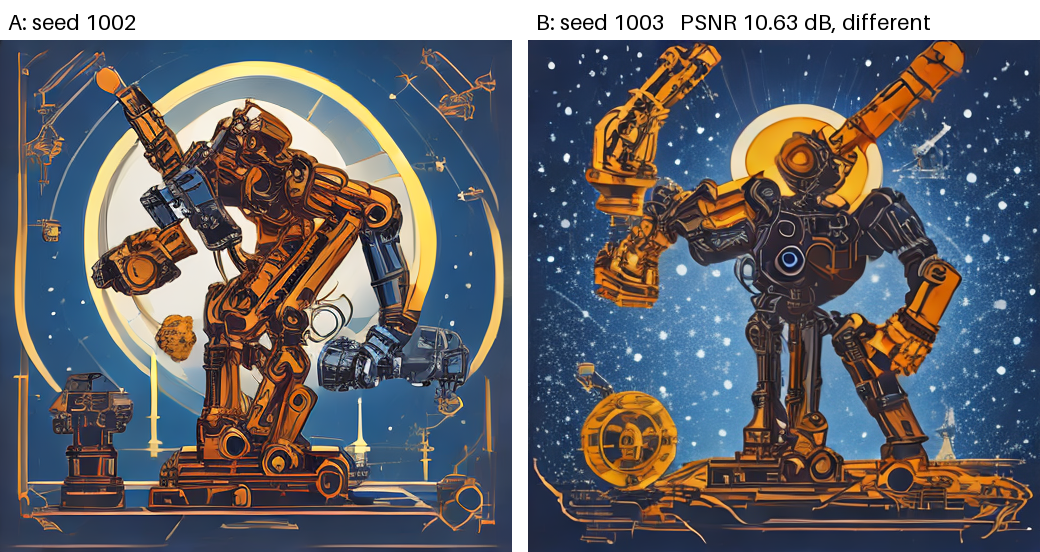

условие A: seed 1002, SHA-256 403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d
условие B: seed 1003, SHA-256 098ebd438eb3befedd979cf5edc0a71ff403f3ae22a664e1644d4309f93eca08


In [10]:
from PIL import Image, ImageDraw, ImageFont

img_a = img
img_b = L.generate(pipe, PROMPT, SEED + 1)[0]
sha_a, sha_b = L.sha(L.png_bytes(img_a)), L.sha(L.png_bytes(img_b))
print("A совпадает с A из variant_summary:", sha_a == S["sha_a"])
print("B совпадает с B из variant_summary:", sha_b == S["sha_b"])

pair = ART / "pair"
pair.mkdir(parents=True, exist_ok=True)
(pair / f"A_seed{SEED}.png").write_bytes(L.png_bytes(img_a))
(pair / f"B_seed{SEED + 1}.png").write_bytes(L.png_bytes(img_b))

try:
    font = ImageFont.load_default(size=22)
except TypeError:
    font = ImageFont.load_default()
gap, head = 16, 40
comp = Image.new("RGB", (2 * SIZE + gap, SIZE + head), "white")
comp.paste(img_a, (0, head))
comp.paste(img_b, (SIZE + gap, head))
d = ImageDraw.Draw(comp)
d.text((8, 8), f"A: seed {SEED}", fill="black", font=font)
d.text((SIZE + gap + 8, 8), f"B: seed {SEED + 1}   PSNR {S['psnr']:.2f} dB, {S['verdict']}", fill="black", font=font)
comp.save(pair / "comparison.png")
display(comp)

# Артефакты варианта (variants_lr05.json): result.png и manifest.json для условий A и B
for tag, im, sd in (("A", img_a, SEED), ("B", img_b, SEED + 1)):
    cdir = ART / f"condition_{tag}"
    cdir.mkdir(parents=True, exist_ok=True)
    png = L.png_bytes(im)
    (cdir / "result.png").write_bytes(png)
    cm = dict(manifest, seed=sd, sha256=L.sha(png), condition=tag, generation_seconds=None)
    (cdir / "manifest.json").write_text(json.dumps(cm, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"условие {tag}: seed {sd}, SHA-256 {cm['sha256']}")


**Визуальная оценка пары (требование варианта 2).** Узнаётся ли на обоих изображениях силуэт механической руки и остаётся ли он главным объектом кадра:

* **A (seed 1002).** В центре — многозвенная конструкция из янтарно-оранжевых манипуляторов с
  синими узлами на платформе; верхний манипулятор с захватом поднят влево вверх. За ней —
  светлый круг-ореол с янтарной каймой, фон тёмно-синий. Механическая рука узнаётся сразу,
  конструкция занимает около двух третей кадра и однозначно главный объект.
* **B (seed 1003).** В центре — механическая фигура с тёмным корпусом и синим «глазом»,
  два янтарных манипулятора подняты в стороны; за ней янтарный диск, фон — тёмно-синее
  звёздное небо, внизу слева — янтарная шестерня. Механические руки узнаются, объект стоит
  в центре и остаётся главным.
* **Общее.** Палитра синий/янтарный сохранилась на обоих изображениях; текста, логотипов и
  людей нет. Смена seed изменила позу и число манипуляторов, фон (ореол против звёздного неба)
  и распределение света, но не смысл запроса.
* **Отклонение от брифа на обоих.** Вместо силуэта (плоской тёмной фигуры) модель нарисовала
  объёмную детализированную конструкцию, местами похожую на робота целиком, а не на одну руку;
  по краям есть мелкие посторонние детали (в A — эскизы механизмов в углах, в B — кран справа).
  Это проявляется при обоих seed, то есть относится к модели и запросу при одном шаге, а не к
  условию варианта.

**Итог:** требование выполнено — на обоих изображениях механическая рука узнаётся и остаётся
главным объектом кадра. Оценка субъективная, сделана одним наблюдателем по `artifacts/pair/comparison.png`.

## Шаг 6. Причина различия: отдельный эксперимент

Шаг 6 плана (`psnr_fixed_noise`) относится к условию 4 «float16 и float32», поэтому
`variant_summary` возвращает `psnr_fixed_noise = None`. Для своего условия причину различия
проверяю отдельным экспериментом. Гипотеза о причине: seed задаёт только начальный
латентный шум, а запрос, веса и вычисления одинаковы. Проверка в три шага:

1. строю начальный шум для seed 1002 и 1003 тем же способом, что и конвейер (генератор на CPU,
   тип вычислений конвейера) и сравниваю тензоры: они должны быть разными и некоррелированными;
2. передаю в конвейер готовый шум seed 1003 через аргумент `latents`, без генератора: изображение
   должно совпасть с B бит в бит;
3. то же для шума seed 1002 и изображения A.

Если 2 и 3 выполняются, всё различие A и B объясняется начальным шумом, а не чем-то ещё в
конвейере.


In [11]:
import numpy as np

shape = (1, pipe.unet.config.in_channels, SIZE // 8, SIZE // 8)
noise = {s: torch.randn(shape, generator=torch.Generator(device="cpu").manual_seed(s), dtype=pipe.unet.dtype)
         for s in (SEED, SEED + 1)}
na, nb = (noise[s].float().flatten().numpy() for s in (SEED, SEED + 1))
print(f"шум seed {SEED} и {SEED + 1}: совпадает: {np.array_equal(na, nb)}, корреляция {np.corrcoef(na, nb)[0, 1]:+.4f}")

CAUSE = {}
for s, ref, tag in ((SEED, sha_a, "A"), (SEED + 1, sha_b, "B")):
    x = pipe(prompt=PROMPT, num_inference_steps=STEPS, guidance_scale=GUIDANCE, height=SIZE, width=SIZE,
             latents=noise[s].to(pipe.device)).images[0]
    CAUSE[tag] = L.sha(L.png_bytes(x)) == ref
    print(f"готовый шум seed {s} без генератора → изображение {tag} бит в бит: {CAUSE[tag]}")


шум seed 1002 и 1003: совпадает: False, корреляция -0.0018
готовый шум seed 1002 без генератора → изображение A бит в бит: True
готовый шум seed 1003 без генератора → изображение B бит в бит: True


## Шаг 7. Намеренная ошибка: общий генератор

Ошибка из демо указаний воспроизводится на своём брифе и seed: один объект
`torch.Generator` создаётся один раз и передаётся в два вызова конвейера подряд. Генератор
хранит состояние, которое сдвигается при первом вызове, поэтому второй вызов получает
другой шум. Ожидается: первое изображение совпадает с эталоном из `manifest.json`,
второе — нет; PSNR между ними ниже 40 дБ. Код повторяет демо дословно (вызов конвейера
без явного размера — по умолчанию у sd-turbo 512 × 512). Оба изображения и метрики
сохраняются в `artifacts/error_shared_generator/`.

Исправление — создавать генератор внутри каждого запуска:
`torch.Generator(device="cpu").manual_seed(seed)`, как это делает `L.generate`;
его работоспособность уже показал повтор на шаге 4.

In [12]:
g = torch.Generator(device="cpu").manual_seed(SEED)
e1 = pipe(prompt=PROMPT, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
e2 = pipe(prompt=PROMPT, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
sha_e1, sha_e2 = L.sha(L.png_bytes(e1)), L.sha(L.png_bytes(e2))
psnr_e = L.psnr_db(e1, e2)

err = ART / "error_shared_generator"
err.mkdir(parents=True, exist_ok=True)
(err / "run1.png").write_bytes(L.png_bytes(e1))
(err / "run2.png").write_bytes(L.png_bytes(e2))
err_info = dict(seed=SEED, sha256_run1=sha_e1, sha256_run2=sha_e2,
                run1_equals_reference=sha_e1 == manifest["sha256"], run2_equals_reference=sha_e2 == manifest["sha256"],
                psnr_db=round(psnr_e, 2), max_diff=L.max_abs_diff(e1, e2), verdict=L.classify(psnr_e))
(err / "result.json").write_text(json.dumps(err_info, ensure_ascii=False, indent=2), encoding="utf-8")

print("SHA-256 первого запуска:", sha_e1)
print("SHA-256 второго запуска:", sha_e2)
print("общий генератор: первый запуск совпал с эталоном:", err_info["run1_equals_reference"])
print("общий генератор: второй запуск совпал с эталоном:", err_info["run2_equals_reference"])
print("PSNR между первым и вторым запуском, дБ:", err_info["psnr_db"], "| вердикт:", err_info["verdict"])

SHA-256 первого запуска: 403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d
SHA-256 второго запуска: 0e1a569aa69b4ab77ccb61c79e75188089f77be3cfe33679d6c09540c5b49361
общий генератор: первый запуск совпал с эталоном: True
общий генератор: второй запуск совпал с эталоном: False
PSNR между первым и вторым запуском, дБ: 9.25 | вердикт: different


## Шаг 8. Итог: контрольные суммы артефактов

Последняя ячейка выводит размер и SHA-256 каждого файла в `artifacts/` и записывает их
в `artifacts/SHA256SUMS` (формат `sha256sum`): по этому списку можно проверить, что файлы,
перенесённые в репозиторий, не изменились. Выводится и общее время выполнения
ноутбука.

In [13]:
lines = []
for p in sorted(ART.rglob("*")):
    if p.is_file() and p.name != "SHA256SUMS":
        rel = p.relative_to(ART).as_posix()
        h = hashlib.sha256(p.read_bytes()).hexdigest()
        lines.append(f"{h}  {rel}")
        print(f"{h}  {p.stat().st_size:>8}  {rel}")
(ART / "SHA256SUMS").write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"\nФайлов: {len(lines)} | общее время выполнения ноутбука: {(time.perf_counter() - T_START) / 60:.1f} мин")

ade07b6388a0b7a5be1204b1aba599195549e60e6109e39f95701a8d7490b118      1146  condition_A/manifest.json
403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d    446291  condition_A/result.png
e890e7acb05b0f4af40af6c57295ede9961d8ea2f74d38631a6884b96cf69a9d      1146  condition_B/manifest.json
098ebd438eb3befedd979cf5edc0a71ff403f3ae22a664e1644d4309f93eca08    490618  condition_B/result.png
46bd2feb9b0b16f4ea294237fd0520172ebc281b3727e777a4f3407a7a0912e8       319  error_shared_generator/result.json
403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d    446291  error_shared_generator/run1.png
0e1a569aa69b4ab77ccb61c79e75188089f77be3cfe33679d6c09540c5b49361    507118  error_shared_generator/run2.png
403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d    446291  pair/A_seed1002.png
098ebd438eb3befedd979cf5edc0a71ff403f3ae22a664e1644d4309f93eca08    490618  pair/B_seed1003.png
39826eb4f40008e298d87e618e1b4430496eac7c4940d98c8b0b8561dfcbdf9c    950528  pai

## Демонстрационный скрипт преподавателя

Демонстрационный вариант указаний (бриф 1, seed 20260919, условие «повтор») запускается скриптом преподавателя `lab05_demo.py` без изменений. Файл записывается ячейкой `%%writefile` (текст побайтно совпадает с выданным) и выполняется в подпапке `demo/`, чтобы его `artifacts/run_001` не перезаписал результаты варианта. После запуска SHA-256 демонстрационного изображения сравнивается с указанным в разделе 6.3 (Colab, T4): совпадение возможно только на той же модели GPU и тех же версиях библиотек, несовпадение означает смену платформы, а не ошибку (раздел 2.2 указаний).


In [14]:
%%writefile lab05_demo.py
# ЛР 5, демонстрационный вариант: один запуск, манифест, повтор, намеренная ошибка (общий генератор).
import json, pathlib, platform, sys, time
import torch, diffusers, transformers, PIL
import lab05_lib as L

out = pathlib.Path("artifacts/run_001")
out.mkdir(parents=True, exist_ok=True)
PROMPT, SEED, STEPS, GUIDANCE, SIZE = L.BRIEFS[0], 20260919, 1, 0.0, 512

t0 = time.perf_counter()
pipe = L.load_pipe()
load_s = time.perf_counter() - t0
L.generate(pipe, PROMPT, 1)  # прогрев: первый вызов включает накладные расходы
t0 = time.perf_counter()
img = L.generate(pipe, PROMPT, SEED, STEPS, GUIDANCE, SIZE)[0]
gen_s = time.perf_counter() - t0

data = L.png_bytes(img)
(out / "result.png").write_bytes(data)
manifest = dict(
    model_id=L.MODEL_ID, revision=L.REVISION, prompt=PROMPT, seed=SEED, steps=STEPS, guidance_scale=GUIDANCE, size=SIZE,
    generator_device="cpu", dtype="float16", device=torch.cuda.get_device_name(0), platform=platform.platform(),
    python=sys.version.split()[0],
    packages={"torch": torch.__version__, "diffusers": diffusers.__version__,
              "transformers": transformers.__version__, "pillow": PIL.__version__},
    load_seconds=round(load_s, 1), generation_seconds=round(gen_s, 2),
    image_size=list(img.size), image_mode=img.mode, sha256=L.sha(data))
(out / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(manifest, ensure_ascii=False, indent=2))

# Повтор в тех же условиях: свежий генератор с тем же seed.
again = L.generate(pipe, PROMPT, SEED, STEPS, GUIDANCE, SIZE)[0]
print("повтор, SHA-256 совпал:", L.sha(L.png_bytes(again)) == manifest["sha256"])

# Намеренная ошибка: один генератор на два запуска (его состояние сдвигается после первого вызова).
g = torch.Generator(device="cpu").manual_seed(SEED)
e1 = pipe(prompt=PROMPT, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
e2 = pipe(prompt=PROMPT, num_inference_steps=STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
print("общий генератор: первый запуск совпал с эталоном:", L.sha(L.png_bytes(e1)) == manifest["sha256"])
print("общий генератор: второй запуск совпал с эталоном:", L.sha(L.png_bytes(e2)) == manifest["sha256"])
print("PSNR между первым и вторым запуском, дБ:", round(L.psnr_db(e1, e2), 2))


Writing lab05_demo.py


In [15]:
import runpy, torch
DEMO = WORK / "demo"
DEMO.mkdir(exist_ok=True)
if torch.cuda.is_available():
    os.chdir(DEMO)   # демонстрационный скрипт пишет файлы по относительным путям — отдельная папка, чтобы не перезаписать результаты варианта
    try:
        runpy.run_path(str(WORK / "lab05_demo.py"), run_name="__main__")
    finally:
        os.chdir(WORK)
    ref = "ac45a7ba8c514b22c1b4cbe0e5c3cfdec62ee3d076b633aaeeadbca43f8a04e9"   # раздел 6.3 указаний, Colab T4
    got = json.loads((DEMO / "artifacts/run_001/manifest.json").read_text(encoding="utf-8"))["sha256"]
    print("SHA-256 демонстрационного запуска совпал с указаниями:", got == ref)
else:
    print("CUDA недоступна: демонстрационный скрипт рассчитан на GPU и не запускался")


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

{
  "model_id": "stabilityai/sd-turbo",
  "revision": "b261bac6fd2cf515557d5d0707481eafa0485ec2",
  "prompt": "editorial poster concept for a robotics festival, glowing mechanical arm silhouette, deep blue and amber palette, clean composition, no text, no logo, no people",
  "seed": 20260919,
  "steps": 1,
  "guidance_scale": 0.0,
  "size": 512,
  "generator_device": "cpu",
  "dtype": "float16",
  "device": "Tesla T4",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "python": "3.13.15",
  "packages": {
    "torch": "2.11.0+cu130",
    "diffusers": "0.40.0",
    "transformers": "5.16.1",
    "pillow": "11.3.0"
  },
  "load_seconds": 3.5,
  "generation_seconds": 0.28,
  "image_size": [
    512,
    512
  ],
  "image_mode": "RGB",
  "sha256": "7daa342ac2719f616aac75a42b836315c54ac5491fd3e56768f541ae48a1bf52"
}
повтор, SHA-256 совпал: True
общий генератор: первый запуск совпал с эталоном: True
общий генератор: второй запуск совпал с эталоном: False
PSNR между первым и вторым запуск

## Вывод

**Условие варианта (seed 1002 против seed 1003): вердикт different, гипотеза подтвердилась.**
SHA-256 A и B различны, пиксели не совпадают, максимум модуля различия 254 из 255,
PSNR **10,63 дБ** — внутри прогноза 8–15 дБ, записанного до запуска, и далеко ниже допуска 40 дБ.

**Что фиксирует seed.** Только начальный латентный шум. Отдельный эксперимент (шаг 6) это
подтвердил: шум seed 1002 и 1003 различен и не коррелирован (коэффициент корреляции −0,0018),
а поданный в конвейер готовым тензором через `latents`, без генератора, он воспроизвёл A и B
бит в бит. Значит, всё различие пары объясняется начальным шумом, а не состоянием конвейера,
прогревом или порядком вызовов.

**Чего seed не фиксирует:** модель и ревизию, запрос, число шагов, guidance, размер, тип
данных шума, устройство генератора, версии библиотек и сборку CUDA. Последнее видно на демо
преподавателя: тот же seed 20260919 на той же Tesla T4 дал SHA-256 `7daa342a…` вместо
`ac45a7ba…` из указаний; единственное записанное отличие среды — torch 2.11.0+**cu130**
вместо +**cu128** (CUDA 13.0 против 12.8). PSNR намеренной ошибки демо — 11,15 дБ против
11,14 дБ в указаниях: изображения разошлись на уровне численного шума, а не по содержанию.

**Воспроизводимость в этой среде** — побитовая: повтор со свежим генератором дал тот же
SHA-256; в новом сеансе (среда выполнения удалена и создана заново, веса скачаны заново)
SHA-256 базового запуска `403134b8…` совпал с первым сеансом, изображение B и PSNR пары
совпали до последнего знака, демо в обоих сеансах дало один и тот же `7daa342a…`.

**Намеренная ошибка.** Один генератор на два вызова: первое изображение совпало с эталоном,
второе нет, PSNR 9,25 дБ (different). Исправление — создавать генератор внутри каждого
запуска, как `L.generate`; повтор на шаге 4 это подтверждает.

**Визуально** на обоих изображениях механическая рука узнаётся и остаётся главным объектом,
палитра синий/янтарный сохранена. Различие A и B — смена входа модели, а не нестабильность.
Вывод относится к одной паре seed, брифу 1 и среде Colab / Tesla T4 / torch 2.11.0+cu130.

## Ограничения

* **Одна пара seed и один бриф.** Вердикт different для seed + 1 ожидаем всегда, но само число
  10,63 дБ для другой пары seed будет другим: три пары с независимым шумом в этой работе дали
  9,25; 10,63 и 11,15 дБ.
* **PSNR — численная мера, а не оценка качества.** Визуальная оценка субъективна и сделана
  одним наблюдателем.
* **Одна среда.** Побитовая воспроизводимость доказана только для Colab, Tesla T4, float16,
  torch 2.11.0+cu130, diffusers 0.40.0, transformers 5.16.1. На другой видеокарте или сборке
  torch/CUDA SHA-256 будут другими — это прямо показал демонстрационный запуск.
* **Не всё окружение записано в манифест.** Манифест следует образцу указаний (torch,
  diffusers, transformers, Pillow); версии драйвера NVIDIA, accelerate и safetensors в него
  не попали. Окружение Colab не закреплено: torch предустановлен и может обновиться,
  transformers при запуске доустановлен до 5.16.1.
* **Эксперимент о причине различия** добавлен после первого сеанса и выполнен во втором;
  гипотеза и допуск после запуска не менялись.
* **Лицензия.** Stability AI Community License: учебное некоммерческое использование; при
  распространении изображений нужны уведомление о лицензии и «Powered by Stability AI».
  Модель по карточке не выводит читаемый текст, а люди и лица у неё получаются неверно.
* **Время генерации** (0,39 с в первом сеансе, 0,33 с во втором) зависит от состояния GPU и в
  сравнение не входит.

## Паспорт эксперимента

| Поле | Значение |
| --- | --- |
| Работа, вариант | ЛР №5, вариант 2: бриф 1 «афиша фестиваля робототехники» × условие 2 «seed и seed + 1» (`seed_plus_1`) |
| Исполнитель | Яковенко Максим Михайлович, Т26ИИКТ-МИК11 |
| Модель и ревизия | `stabilityai/sd-turbo`, `b261bac6fd2cf515557d5d0707481eafa0485ec2`; файлы fp16 (`variant="fp16"`, safetensors) |
| Лицензия | Stability AI Community License Agreement (5 июля 2024 г., `LICENSE.md` на ревизии) и Acceptable Use Policy; учебное некоммерческое использование; при распространении — уведомление о лицензии и «Powered by Stability AI» |
| Запрос | `BRIEFS[0]`: «editorial poster concept for a robotics festival, glowing mechanical arm silhouette, deep blue and amber palette, clean composition, no text, no logo, no people» |
| seed | A — 1002 (базовый запуск), B — 1003; прогрев — 1; демо — 20260919 |
| Шаги, guidance, размер | 1; 0,0; 512 × 512 |
| Генератор | `torch.Generator` на CPU, свежий на каждый запуск |
| Тип вычислений | float16 (CUDA доступна, адаптация библиотеки не применялась) |
| Среда | Google Colab, GPU Tesla T4 (14,6 ГиБ), CUDA в torch 13.0; 2 ядра CPU, ОЗУ 12,7 ГиБ; Linux-6.6.122+-x86_64-with-glibc2.39 |
| Версии | Python 3.13.15; torch 2.11.0+cu130; diffusers 0.40.0; transformers 5.16.1; Pillow 11.3.0; numpy 2.1.3 |
| Библиотека | `lab05_lib.py` без изменений: 6447 байт, SHA-256 `4eb176506585ffcda1702605a767309fb451808229c3622f80ce882b7fa2ce1a` |
| SHA-256 A (`run_001`, `condition_A`) | `403134b8e34029d144d41b14a9de11273a7a6dc3defb79fc871aa181b48faf1d` |
| SHA-256 B (`condition_B`) | `098ebd438eb3befedd979cf5edc0a71ff403f3ae22a664e1644d4309f93eca08` |
| Допуск (до запуска) | identical — побитовое совпадение; close — PSNR ≥ 40 дБ; different — PSNR < 40 дБ (`reports/journal.md`, коммит `be8fcd9`) |
| Результат | different: пиксели не совпадают, максимум различия 254, PSNR 10,63 дБ |
| Причина | только начальный шум: готовый шум seed 1002 / 1003 через `latents` воспроизводит A / B бит в бит |
| Воспроизводимость | повтор в сеансе — SHA-256 совпал; новый сеанс — SHA-256 A и B совпали; демо `7daa342a…` ≠ `ac45a7ba…` из указаний (torch +cu130 против +cu128) |
| Намеренная ошибка | общий генератор: run1 = эталон, run2 `0e1a569a…`, PSNR 9,25 дБ |
| Артефакты | `artifacts/`: `run_001`, `condition_A`, `condition_B`, `pair`, `error_shared_generator`, `variant_02_summary.json`; контрольные суммы — `SHA256SUMS` (13 файлов) |
| Репозиторий | https://github.com/ykvnkm/ai-in-creative-industries/tree/main/LR05 |